# 03 — UC2 FedGen (KD-gen)

Train FedGen (Data-Free Knowledge Distillation with Generative Model)
across the alpha sweep. This is the main algorithm under study.

We test two variants:
- **FedGen (full)**: full model + generator exchange
- **FedGen (partial)**: only shared layers + generator (much lower comm cost)

Paper reference: Zhu et al. "Data-Free Knowledge Distillation for 
Heterogeneous Federated Learning" (ICML 2021)

Applied to regression: Salami, Wilhelmi et al. "Distributed Learning 
for Wi-Fi AP Load Prediction" (2024)

In [1]:
import sys, os
sys.path.append("..")
import UC2Utils as uc2
sys.path.insert(0, uc2.LIB_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from collections import Counter

sys.path.insert(0, uc2.LIB_DIR)

print(f"Device: {uc2.DEFAULT_CONFIG['device']}")

Device: cuda:0


## Configuration

In [2]:
ALPHAS = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
MODEL = "lstm"
RETRAIN = True

OVERRIDES = dict(
    num_glob_iters=200,
    local_epochs=20,
    num_users=20,
    early_stopping_patience=20,
    ensemble_lr=1e-4,
    batch_size=32,
)

## Part A: FedGen (Full Model Exchange)

Standard FedGen: aggregates full model + trains/shares the generator.
Communication cost: C = (2|θ| + |ω|) × R × |S|

In [3]:
import os
 
# --- config: must match what notebook 00 used to generate new partitions ---
NEWPART_SUBDIR = "new_partitions"
_NP_LOOKBACK = uc2.DEFAULT_CONFIG["lookback"]   # 60
_NP_STEPS    = uc2.DEFAULT_CONFIG["steps"]      # 1
 
# keep handles to the originals so we can toggle / restore
_orig_make_args     = uc2.make_args
_orig_result_exists = uc2.result_exists
_orig_load_result   = uc2.load_result
 
_NEWPART_ON = {"flag": False}
 
 
def _newpart_dataset_path():
    return os.path.join(uc2.DATA_PART, NEWPART_SUBDIR,
                        f"lookback_{_NP_LOOKBACK}", f"steps_{_NP_STEPS}")
 
 
def _redirect_result_path(result_path, algorithm, alpha, model):
    """Force any result path under RESULTS/newpart/ so old results stay intact."""
    base = os.path.join(uc2.RESULTS, "newpart")
    if result_path is None:
        return os.path.join(base, algorithm.lower(), f"alpha_{alpha}", model, "rep_0")
    # explicit path (e.g. FedGen-partial): re-root it under newpart/, preserving tail
    rel = os.path.relpath(os.path.abspath(result_path), os.path.abspath(uc2.RESULTS))
    return os.path.join(base, rel)
 
 
def _patched_make_args(algorithm, alpha, result_path=None, **overrides):
    args = _orig_make_args(algorithm, alpha, result_path=result_path, **overrides)
    if _NEWPART_ON["flag"]:
        args.dataset_path = _newpart_dataset_path()
        model = {**uc2.DEFAULT_CONFIG, **overrides}["model"]
        new_rp = _redirect_result_path(result_path, algorithm, alpha, model)
        new_rp = os.path.relpath(new_rp)          # lib dislikes spaces in abs paths
        os.makedirs(new_rp, exist_ok=True)
        args.result_path = new_rp
    return args
 
 
def _patched_result_exists(algorithm, alpha, model="lstm"):
    if _NEWPART_ON["flag"]:
        p = os.path.join(uc2.RESULTS, "newpart", algorithm.lower(),
                         f"alpha_{alpha}", model, "rep_0", "full_results.pkl")
        return os.path.exists(p)
    return _orig_result_exists(algorithm, alpha, model)
 
 
def _patched_load_result(algorithm, alpha, model="lstm"):
    if _NEWPART_ON["flag"]:
        import pickle
        p = os.path.join(uc2.RESULTS, "newpart", algorithm.lower(),
                         f"alpha_{alpha}", model, "rep_0", "full_results.pkl")
        with open(p, "rb") as f:
            return pickle.load(f)
    return _orig_load_result(algorithm, alpha, model)
 
 
def use_new_partitions(on=True):
    """Toggle label-skew partitions on/off for all subsequent run_experiment calls."""
    _NEWPART_ON["flag"] = bool(on)
    uc2.make_args     = _patched_make_args     if on else _orig_make_args
    uc2.result_exists = _patched_result_exists if on else _orig_result_exists
    uc2.load_result   = _patched_load_result   if on else _orig_load_result
    state = "NEW label-skew" if on else "ORIGINAL AP-ID"
    print(f"[wiring] partitions = {state}")
    if on:
        dp = _newpart_dataset_path()
        print(f"[wiring] dataset_path -> {dp}")
        print(f"[wiring] results      -> {os.path.join(uc2.RESULTS, 'newpart', '...')}")
        # fail fast if partitions are missing
        miss = [a for a in ALPHAS if not os.path.exists(
            os.path.join(dp, f"u{uc2.DEFAULT_CONFIG['n_users']}-alpha{a}-ratio1",
                         "train", "train.pt"))]
        if miss:
            print(f"[wiring] ⚠️  MISSING new partitions for α={miss} — "
                  f"run notebook 00 generation cell first!")
            

In [4]:
# In 02 (FedAvg) set RETRAIN=True the first time so it actually trains on the
# new partitions instead of loading old results:
#     RETRAIN = True
# Then:
use_new_partitions(True)
 
# ...now run the EXISTING training-loop cell unchanged...
# (results_fedavg / results_fedgen_full get populated from new partitions)

[wiring] partitions = NEW label-skew
[wiring] dataset_path -> /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/data/partitions/new_partitions/lookback_60/steps_1
[wiring] results      -> /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/results/newpart/...


In [5]:
import inspect, FLAlgorithms.users.userbase as ub
print("userbase loaded from:", ub.__file__)
print("User has save_model:", hasattr(ub.User, "save_model"))
print("User has get_next_train_batch:", hasattr(ub.User, "get_next_train_batch"))

# And check the actual user instance from the failed run, if `server` exists:
from FLAlgorithms.users.userpFedGen import UserpFedGen
print("UserpFedGen MRO:", [c.__name__ for c in UserpFedGen.__mro__])
print("UserpFedGen has save_model:", hasattr(UserpFedGen, "save_model"))

userbase loaded from: /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/userbase.py
User has save_model: True
User has get_next_train_batch: True
UserpFedGen MRO: ['UserpFedGen', 'User', 'object']
UserpFedGen has save_model: True


In [6]:
with open("/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/userbase.py") as f:
    src = f.read()
print("save_model in file:", "def save_model" in src)
print("get_next_train_batch in file:", "def get_next_train_batch" in src)
# confirm they're indented as methods (4 spaces), not accidentally dedented
import re
print("save_model indented as method:", bool(re.search(r"\n    def save_model", src)))
print("get_next_train_batch indented as method:", bool(re.search(r"\n    def get_next_train_batch", src)))

save_model in file: True
get_next_train_batch in file: True
save_model indented as method: True
get_next_train_batch indented as method: True


In [7]:
results_fedgen_full = {}

for alpha in ALPHAS:
    print(f"\n{'='*60}")
    print(f"  FedGen (full) — α={alpha}")
    print(f"{'='*60}")

    if not RETRAIN and uc2.result_exists("FedGen", alpha):
        print(f"  [✓] Already done — loading results.")
        results_fedgen_full[alpha] = uc2.load_result("FedGen", alpha)
        continue

    try:
        server, result = uc2.run_experiment(
            algorithm="FedGen",
            alpha=alpha,
            **OVERRIDES
        )
        results_fedgen_full[alpha] = result

        # Print final metrics
        glob_metrics = result["metrics"]["glob_test_metric"]
        if glob_metrics:
            best_idx = np.argmin([m.get("unscaled_mae", float("inf"))
                                  for m in glob_metrics])
            best = glob_metrics[best_idx]
            print(f"\n  Best round: {best_idx}")
            print(f"  MAE (scaled):   {best.get('mae', 'N/A'):.4f}")
            print(f"  MAE (unscaled): {best.get('unscaled_mae', 'N/A'):.4f}")
            print(f"  MAPE:           {best.get('unscaled_mape', 'N/A'):.4f}")

        per_user_mae = result.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
        if per_user_mae:
            print(f"\n  Per-user MAE: mean={np.mean(per_user_mae):.4f}, "
                  f"std={np.std(per_user_mae):.4f}, "
                  f"CV={np.std(per_user_mae)/np.mean(per_user_mae):.3f}")

    except Exception as e:
        print(f"  [ERROR] {e}")
        import traceback
        traceback.print_exc()


  FedGen (full) — α=0.01
Creating model for flags-regression
Network configs: ['LSTM-480', 'F']


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Dataset flags-regression
Build layer 64 X 256
Build last layer 256 X 32
ensemble_lr: 0.0003
ensemble_batch_size: 128
unique_labels: None
latent_layer_idx: -1
label embedding 1
ensemeble learning rate: 0.0003
ensemeble alpha = 1, beta = 0, eta = 1
generator alpha = 10, beta = 10


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


Number of Train/Test samples: 88894 60000
Data from 20 users in total.
Finished creating FedGen server.

Training FedGen | α=0.01 | model=lstm



-------------Round number:  0  -------------


All users are selected
Average Global Test Metrics: mse = 0.1751, mae = 0.3980, mape = 0.3137, unscaled_mse = 20165.9316, unscaled_mae = 45.6478, unscaled_mape = 244406464.0000,  Loss = 0.3980.
The model is saved!


...

/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/userpFedGen.py:132: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  self.lr_scheduler.step(glob_iter)



User Teacher Loss=0.5939, Latent Loss=0.7996
Generator: Teacher Loss= 3.1562, Student Loss= 0.0000, Diversity Loss = 0.8004, 


-------------Round number:  3  -------------


All users are selected
Average Global Test Metrics: mse = 0.1771, mae = 0.3905, mape = 0.3152, unscaled_mse = 20165.9141, unscaled_mae = 45.6478, unscaled_mape = 780612480.0000,  Loss = 0.3905.
The model is saved!


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/userpFedGen.py:132: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  self.lr_scheduler.step(glob_iter)



User Teacher Loss=0.8682, Latent Loss=1.7611
Generator: Teacher Loss= 2.7138, Student Loss= 0.0000, Diversity Loss = 0.7869, 


-------------Round number:  4  -------------


All users are selected
Average Global Test Metrics: mse = 0.1792, mae = 0.3867, mape = 0.3162, unscaled_mse = 20165.8984, unscaled_mae = 45.6477, unscaled_mape = 1463179136.0000,  Loss = 0.3867.


KeyboardInterrupt: 

In [ ]:
print("Sanity: dataset_path used by make_args right now ->")
_test = uc2.make_args("FedAvg", ALPHAS[0], **OVERRIDES)
print("   ", _test.dataset_path)
assert NEWPART_SUBDIR in _test.dataset_path, "NOT pointing at new partitions!"
print("   ✓ confirmed new partitions are wired in")

Sanity: dataset_path used by make_args right now ->
    /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/data/partitions/new_partitions/lookback_60/steps_1
   ✓ confirmed new partitions are wired in


## Part B: FedGen (Partial — Shared Layers Only)

Only the decoder (last FC layer) is aggregated at the server.
The encoder stays local → much lower communication cost.

Communication cost: C = (2|gr(θ)| + |ω|) × R × |S|
where |gr(θ)| ≈ 0.002 MB vs |θ| = 3.7 MB

**Note**: The `pFedGen` naming triggers `self.personalized = True` and
`self.mode = 'partial'` in the codebase. If this doesn't work with your
version, you can also manually set `specified_mode=True` or modify
the algorithm string.

In [ ]:
results_fedgen_partial = {}

for alpha in ALPHAS:
    print(f"\n{'='*60}")
    print(f"  FedGen (partial) — α={alpha}")
    print(f"{'='*60}")

    # Partial results live under fedgen_partial/
    result_path = os.path.join(
        uc2.RESULTS, "fedgen_partial", f"alpha_{alpha}",
        MODEL, "rep_0"
    )
    result_pkl = os.path.join(result_path, "full_results.pkl")

    if not RETRAIN and os.path.exists(result_pkl):
        print(f"  [✓] Already done — loading results.")
        with open(result_pkl, "rb") as f:
            results_fedgen_partial[alpha] = pickle.load(f)
        continue

    try:
        server, result = uc2.run_experiment(
            algorithm="pFedGen",
            alpha=alpha,
            result_path=result_path,
            **OVERRIDES
        )
        result["algorithm"] = "FedGen_partial"
        results_fedgen_partial[alpha] = result

        glob_metrics = result["metrics"]["glob_test_metric"]
        if glob_metrics:
            best_idx = np.argmin([m.get("unscaled_mae", float("inf"))
                                  for m in glob_metrics])
            best = glob_metrics[best_idx]
            print(f"\n  Best round: {best_idx}")
            print(f"  MAE (scaled):   {best.get('mae', 'N/A'):.4f}")
            print(f"  MAE (unscaled): {best.get('unscaled_mae', 'N/A'):.4f}")

        per_user_mae = result.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
        if per_user_mae:
            print(f"\n  Per-user MAE: mean={np.mean(per_user_mae):.4f}, "
                  f"std={np.std(per_user_mae):.4f}")

    except Exception as e:
        print(f"  [ERROR] {e}")
        import traceback
        traceback.print_exc()


  FedGen (partial) — α=0.01
Creating model for flags-regression
Network configs: ['LSTM-480', 'F']


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Dataset flags-regression
Build layer 64 X 256
Build last layer 256 X 32
ensemble_lr: 0.0003
ensemble_batch_size: 128
unique_labels: None
latent_layer_idx: -1
label embedding 1
ensemeble learning rate: 0.0003
ensemeble alpha = 1, beta = 0, eta = 1
generator alpha = 10, beta = 10


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


Number of Train/Test samples: 88894 60000
Data from 20 users in total.
Finished creating FedGen server.

Training pFedGen | α=0.01 | model=lstm



-------------Round number:  0  -------------


All users are selected
Average Global Test Metrics: mse = 0.1751, mae = 0.3980, mape = 0.3137, unscaled_mse = 20165.9316, unscaled_mae = 45.6478, unscaled_mape = 244406464.0000,  Loss = 0.3980.
  [ERROR] 'UserpFedGen' object has no attribute 'save_model'


...

Traceback (most recent call last):
  File "/tmp/ipykernel_4461/3745522033.py", line 22, in <module>
    server, result = uc2.run_experiment(
                     ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 377, in run_experiment
    metrics = train_server(server, args)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 335, in train_server
    server.train(args)
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serverpFedGen.py", line 100, in train
    user.save_model()
    ^^^^^^^^^^^^^^^
AttributeError: 'UserpFedGen' object has no attribute 'save_model'
/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater th


  FedGen (partial) — α=10.0
Creating model for flags-regression
Network configs: ['LSTM-480', 'F']
Dataset flags-regression
Build layer 64 X 256
Build last layer 256 X 32
ensemble_lr: 0.0003
ensemble_batch_size: 128
unique_labels: None
latent_layer_idx: -1
label embedding 1
ensemeble learning rate: 0.0003
ensemeble alpha = 1, beta = 0, eta = 1
generator alpha = 10, beta = 10


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


Number of Train/Test samples: 88894 60000
Data from 20 users in total.
Finished creating FedGen server.

Training pFedGen | α=10.0 | model=lstm



-------------Round number:  0  -------------


All users are selected
Average Global Test Metrics: mse = 0.1751, mae = 0.3980, mape = 0.3137, unscaled_mse = 20165.9316, unscaled_mae = 45.6478, unscaled_mape = 244406464.0000,  Loss = 0.3980.
  [ERROR] 'UserpFedGen' object has no attribute 'save_model'


Traceback (most recent call last):
  File "/tmp/ipykernel_4461/3745522033.py", line 22, in <module>
    server, result = uc2.run_experiment(
                     ^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 377, in run_experiment
    metrics = train_server(server, args)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/03_FedGen/../UC2Utils.py", line 335, in train_server
    server.train(args)
  File "/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/servers/serverpFedGen.py", line 100, in train
    user.save_model()
    ^^^^^^^^^^^^^^^
AttributeError: 'UserpFedGen' object has no attribute 'save_model'


## Training Curves — Full vs Partial

/tmp/ipykernel_4461/3316062705.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_4461/3316062705.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


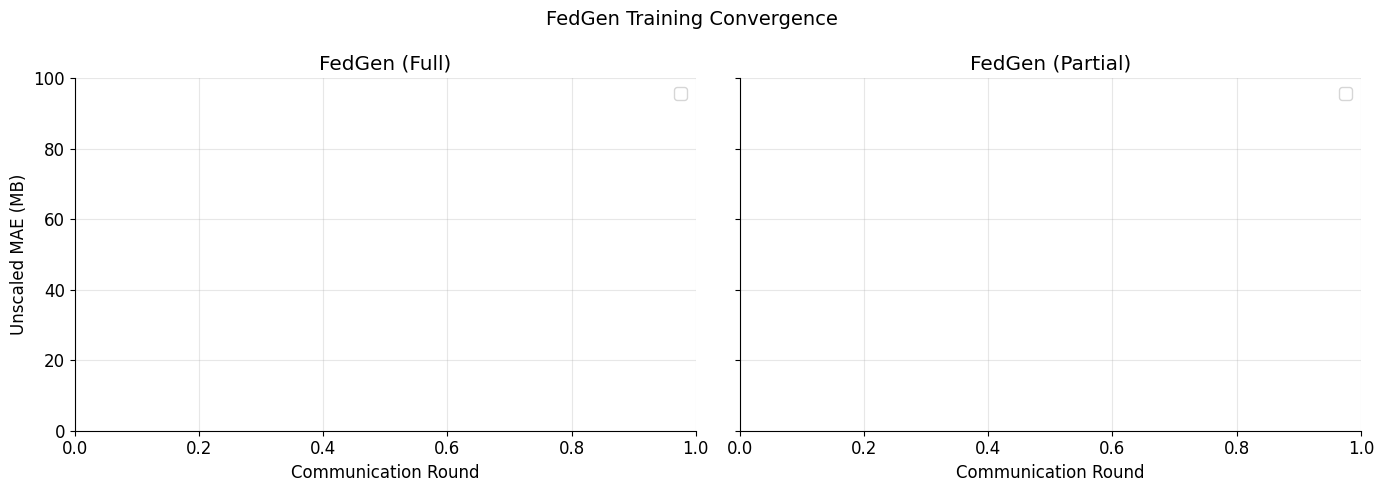

In [ ]:
import matplotlib.pyplot as plt
uc2.setup_plot_style()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Full
ax = axes[0]
for alpha, r in sorted(results_fedgen_full.items()):
    glob_metrics = r["metrics"].get("glob_test_metric", [])
    maes = [m.get("unscaled_mae") for m in glob_metrics]
    ax.plot(maes, label=f"α={alpha}", linewidth=2)
ax.set_ylim(0, 100)
ax.set_xlabel("Communication Round")
ax.set_ylabel("Unscaled MAE (MB)")
ax.set_title("FedGen (Full)")
ax.legend()

# Partial
ax = axes[1]
for alpha, r in sorted(results_fedgen_partial.items()):
    glob_metrics = r["metrics"].get("glob_test_metric", [])
    maes = [m.get("unscaled_mae") for m in glob_metrics]
    ax.plot(maes, label=f"α={alpha}", linewidth=2)
ax.set_ylim(0, 100)
ax.set_xlabel("Communication Round")
ax.set_title("FedGen (Partial)")
ax.legend()

plt.suptitle("FedGen Training Convergence", fontsize=14)
plt.tight_layout()
plt.show()

## Communication Cost Comparison

In [ ]:
print(f"{'α':>5} | {'FedGen Full (MB)':>18} | {'FedGen Partial (MB)':>20} | {'Reduction':>10}")
print("-" * 60)

for alpha in ALPHAS:
    n_full = results_fedgen_full.get(alpha, {}).get("n_rounds", 100)
    n_part = results_fedgen_partial.get(alpha, {}).get("n_rounds", 100)
    
    c_full = uc2.comm_cost_fedgen_full(n_full, 20)
    c_part = uc2.comm_cost_fedgen(n_part, 20)
    
    reduction = (1 - c_part / c_full) * 100 if c_full > 0 else 0
    print(f"{alpha:>5.1f} | {c_full:>18.1f} | {c_part:>20.1f} | {reduction:>9.1f}%")

    α |   FedGen Full (MB) |  FedGen Partial (MB) |  Reduction
------------------------------------------------------------
  0.0 |            15026.0 |                234.0 |      98.4%
  0.1 |            15026.0 |                234.0 |      98.4%
  0.5 |            15026.0 |                234.0 |      98.4%
  1.0 |            15026.0 |                234.0 |      98.4%
  5.0 |            15026.0 |                234.0 |      98.4%
 10.0 |            15026.0 |                234.0 |      98.4%


## Summary

- **FedGen (full)**: similar accuracy to FedAvg but with generator-based 
  regularization. Should degrade less at low α.
- **FedGen (partial)**: massive communication savings (~98% reduction) 
  at some accuracy cost. Key point for the Pareto analysis.
- Results saved to `results/fedgen/` and `results/fedgen_partial/`